# 07 · Deployment — model final, peta risiko 14 hari, dashboard publik, pemantauan
Fase CRISP-DM 6: **Plan deployment → Plan monitoring & maintenance → Produce final report → Review project**.

```
 PIHPS BI (4 jenis pasar) ─┐
 NASA POWER (hujan) ───────┼─► scraper + cache ─► panel bersih ─► label & jaringan ─► fitur ─► LightGBM final
 kalender hari besar ──────┘                                                                   │
                                                                                               ▼
   QR poster ◄── dashboard statis (site/) di GitHub Pages / Vercel ◄── JSON (risiko + alasan SHAP + rambatan)
                        ▲
                        └── update harian otomatis: python run_pipeline.py update  (GitHub Actions / Task Scheduler)
```

| Komponen | File | Keterangan |
|---|---|---|
| Pipeline otomatis | `run_pipeline.py` | `update` (harian), `update --retrain` (bulanan), `evaluate` |
| Model | `models/lgbm_final.txt`, `models/model_meta.json` | LightGBM + ambang alarm + daftar fitur |
| Dashboard | `site/` (`index.html`, `assets/`, `data/*.json`) | HTML statis + Plotly.js, tanpa server, ramah HP |
| Jadwal | `.github/workflows/update-dashboard.yml`, `deployment/update_harian.bat` | Cloud (GitHub Actions) atau laptop (Windows Task Scheduler) |
| QR | `deployment/make_qr.py` → `reports/figures/qr_*.png` | Untuk footer poster |

In [1]:
# --- Setup: path project, modul radarpangan, gaya grafik -----------------------------------
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from radarpangan.config import load_project
cfg, P = load_project(ROOT)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("Project:", ROOT)

Project: /home/claude/MiningProcess


In [2]:
import lightgbm as lgb
from radarpangan import pipeline as PL
from radarpangan.site import export_site
from radarpangan.viz import plot_choropleth, PALETTE
from radarpangan.geo import load_geojson
refs = PL.load_refs(P)
feats = pd.read_parquet(P.processed / "features_final.parquet")
groups = json.loads((P.processed / "feature_groups.json").read_text(encoding="utf-8"))
print(f"Fitur final: {feats.shape[0]:,} baris | data s.d. {feats['date'].max():%d %b %Y}")

Fitur final: 1,533,771 baris | data s.d. 25 Sep 2026


## 7.1 Latih model final
Model dilatih pada **seluruh** data berlabel. 120 hari terakhir dipakai untuk early stopping & memilih ambang alarm, lalu model dilatih ulang pada semua data dengan jumlah pohon terbaik (+10%). Fitur "provinsi pemimpin" memakai jaringan dari seluruh data.

In [3]:
booster, meta = PL.train_final_model(cfg, P, feats, groups)
display(pd.Series({k: v for k, v in meta.items() if k != "features"}, name="model_meta").to_frame())

,model_meta
trained_until,2026-09-11
n_rows,1451057
n_trees,401
alarm_threshold,0.2174
val_pr_auc,0.5677
val_period,"[2026-05-15, 2026-09-11]"


## 7.2 Prediksi risiko 14 hari ke depan + alasan (SHAP)
Level risiko: **Tinggi** = peluang ≥ ambang alarm; **Waspada** = ≥ ½ ambang; **Rendah** = di bawahnya; **Sedang lonjak** = harga sudah naik melewati ambang lonjakan dalam 14 hari terakhir.

In [4]:
risk = PL.predict_latest(cfg, P, booster, meta, feats, refs)
risk.to_csv(P.output / "risk_latest.csv", index=False)
asof = risk["asof"].iloc[0]
print(f"Prediksi per {asof:%A, %d %B %Y} untuk periode {asof + pd.Timedelta(days=1):%d %b} – {asof + pd.Timedelta(days=14):%d %b %Y}")
lvl = risk.pivot_table(index="category", columns="level", values="prob", aggfunc="size").fillna(0).astype(int)
display(lvl[[c for c in ["Sedang lonjak", "Tinggi", "Waspada", "Rendah"] if c in lvl.columns]])
top = risk[risk["level"] == "Tinggi"].sort_values("prob", ascending=False).head(12)
display(top[["province", "commodity", "prob", "r14_now", "reasons"]].rename(columns={"province": "provinsi", "commodity": "komoditas",
        "prob": "peluang", "r14_now": "kenaikan 14 hr", "reasons": "alasan utama (SHAP)"}).style.format(
        {"peluang": "{:.0%}", "kenaikan 14 hr": "{:+.1%}"}).hide(axis="index"))

Prediksi per Friday, 25 September 2026 untuk periode 26 Sep – 09 Oct 2026


level,Sedang lonjak,Tinggi,Waspada,Rendah
category,,,,
Bawang Merah,0,1,5,28
Bawang Putih,0,0,0,34
Beras,1,0,0,199
Cabai Merah,16,12,14,19
Cabai Rawit,6,7,16,35
Daging Ayam,0,0,0,34
Daging Sapi,0,0,0,66
Gula Pasir,0,0,0,67
Minyak Goreng,0,0,0,99


provinsi,komoditas,peluang,kenaikan 14 hr,alasan utama (SHAP)
Nusa Tenggara Timur,Cabai Merah Keriting,52%,+6.6%,"Harga sedang bergejolak: rata-rata ±2,4% per hari (30 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +9,2% dalam 7 hari | Harga 32,6% di bawah rata-rata nasional (berpotensi menyusul naik)"
DKI Jakarta,Cabai Merah Besar,45%,-6.9%,"Harga sedang bergejolak: rata-rata ±2,4% per hari (30 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +6,4% dalam 7 hari | Harga 17,6% di bawah rata-rata nasional (berpotensi menyusul naik)"
Kalimantan Timur,Cabai Merah Keriting,43%,+8.3%,"Harga sedang bergejolak: rata-rata ±1,9% per hari (30 hari terakhir) | Harga +9,7% dalam 7 hari terakhir | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +6,4% dalam 14 hari"
Jawa Tengah,Cabai Merah Besar,42%,+4.2%,"Harga sedang bergejolak: rata-rata ±1,4% per hari (30 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +6,0% dalam 7 hari | Harga 32,1% di bawah rata-rata nasional (berpotensi menyusul naik)"
Kalimantan Utara,Cabai Rawit Merah,39%,+8.0%,"Harga sedang bergejolak: rata-rata ±1,9% per hari (30 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +2,8% dalam 7 hari | Harga +6,3% dalam 1 hari terakhir"
Kepulauan Riau,Cabai Rawit Merah,36%,-1.3%,"Harga sedang bergejolak: rata-rata ±3,4% per hari (30 hari terakhir) | 5 kali lonjakan dalam setahun terakhir | Harga +2,9% dalam 7 hari terakhir"
Maluku,Cabai Merah Keriting,36%,+14.0%,"Harga sedang bergejolak: rata-rata ±3,9% per hari (14 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +19,4% dalam 14 hari | Tinggal 1,0 poin persen lagi menuju ambang lonjakan"
Nusa Tenggara Timur,Cabai Rawit Merah,34%,+4.2%,"Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +7,3% dalam 7 hari | Harga sedang bergejolak: rata-rata ±1,8% per hari (30 hari terakhir) | Harga +1,7% dalam 1 hari terakhir"
Sumatera Barat,Cabai Rawit Hijau,34%,+11.9%,"Harga +10,9% dalam 7 hari terakhir | Harga sedang bergejolak: rata-rata ±2,2% per hari (30 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +1,3% dalam 14 hari"
Banten,Cabai Merah Besar,33%,+2.9%,"Harga sedang bergejolak: rata-rata ±1,7% per hari (30 hari terakhir) | Provinsi ""pemimpin"" (biasanya naik duluan) berubah rata-rata +4,4% dalam 7 hari | Harga 19,0% di bawah rata-rata nasional (berpotensi menyusul naik)"


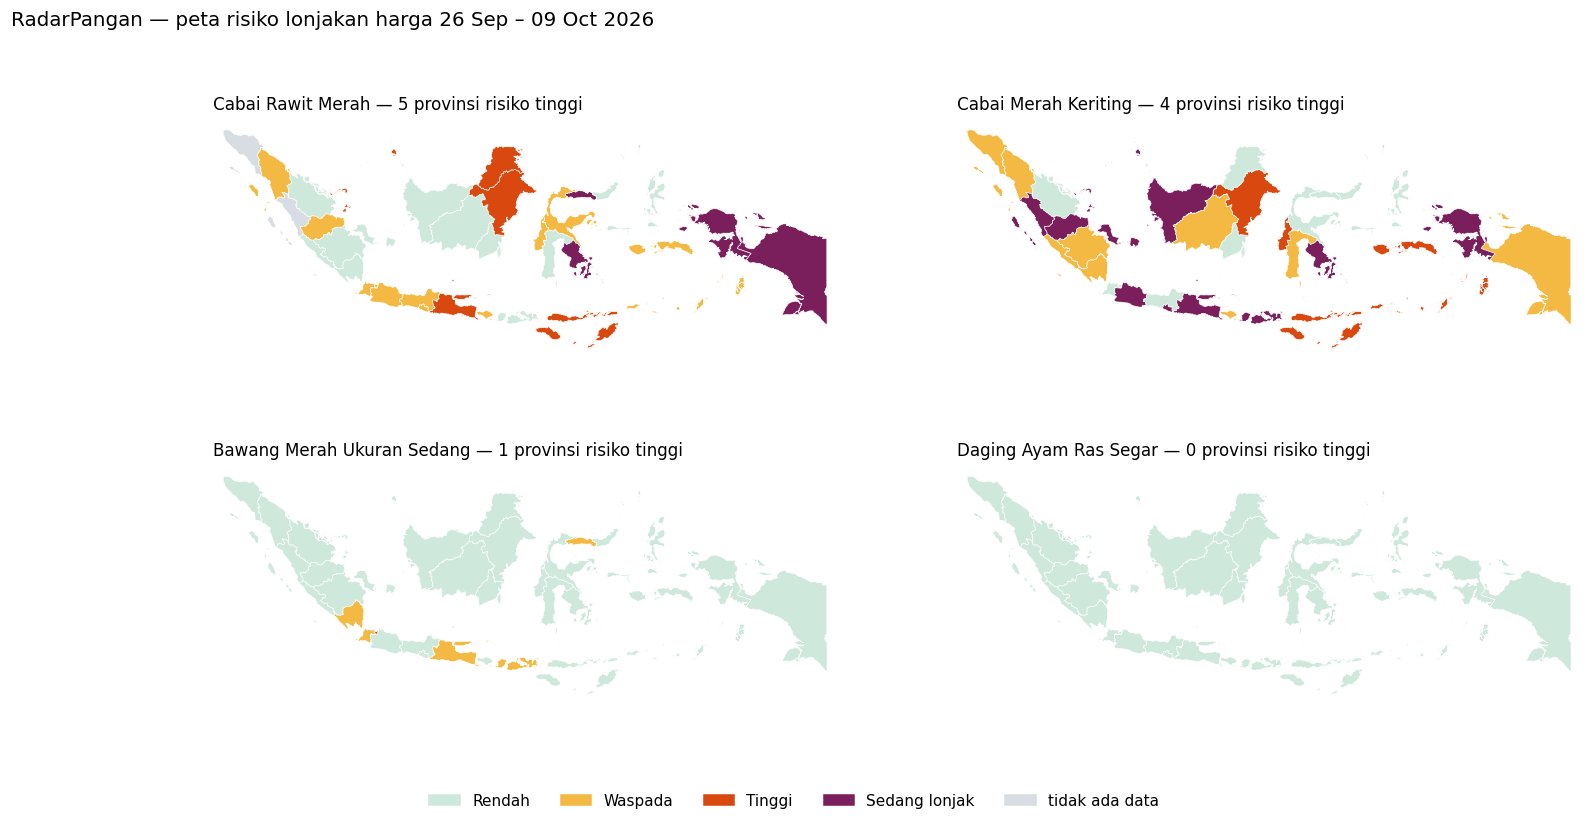

In [5]:
# Peta risiko (gambar statis untuk poster/proposal)
geo = load_geojson(P.external / "indonesia_provinces.geojson")
cmap = {"Rendah": PALETTE["low"], "Waspada": PALETTE["watch"], "Tinggi": PALETTE["high"], "Sedang lonjak": PALETTE["spike"]}
show = ["com_16", "com_14", "com_11", "com_7"]
fig, axes = plt.subplots(2, 2, figsize=(16, 7.5))
for ax, c in zip(axes.ravel(), show):
    r = risk[risk["commodity_id"] == c]
    plot_choropleth(ax, geo, {}, colors={int(p): cmap[l] for p, l in zip(r["province_id"], r["level"])},
                    title=f"{refs['com_name'][c]} — {(r['level'] == 'Tinggi').sum()} provinsi risiko tinggi")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=v, label=k) for k, v in cmap.items()] + [Patch(color=PALETTE["nodata"], label="tidak ada data")],
           loc="lower center", ncol=5, frameon=False)
fig.suptitle(f"RadarPangan — peta risiko lonjakan harga {asof + pd.Timedelta(days=1):%d %b} – {asof + pd.Timedelta(days=14):%d %b %Y}", x=0.01, ha="left", fontsize=13)
fig.savefig(P.figures / "fig_07_01_peta_risiko.png", dpi=170, bbox_inches="tight"); plt.show()

## 7.3 Ekspor dashboard statis (`site/`)
Folder `site/` adalah prototipe untuk QR poster. Cara melihat di laptop:
```bash
python -m http.server 8000 --directory site
# buka http://localhost:8000
```
(Membuka `index.html` langsung dengan klik dua kali tidak bisa karena browser memblokir `fetch` file lokal.)

In [6]:
leaders = {(k.split("|")[0], int(k.split("|")[1])): v for k, v in json.loads((P.processed / "leaders_final.json").read_text(encoding="utf-8")).items()}
panels = {pt: PL.load_panel(P.processed / f"panel_pt{pt}.parquet") for pt in [1, 2, 3, 4] if (P.processed / f"panel_pt{pt}.parquet").exists()}
ev_path = P.tables / "eval_summary.json"
site = export_site(cfg, P, risk, meta, refs, panels, pd.read_parquet(P.processed / "events.parquet"),
                   pd.read_parquet(P.processed / "network_edges_final.parquet"), pd.read_parquet(P.processed / "leader_scores_final.parquet"),
                   leaders, json.loads(ev_path.read_text(encoding="utf-8")) if ev_path.exists() else None)
files = sorted(p for p in site.rglob("*") if p.is_file())
print(f"{len(files)} file, total {sum(p.stat().st_size for p in files) / 1e6:.1f} MB di {site}")
for p in files[:12]:
    print(f"  {p.relative_to(site)}  ({p.stat().st_size / 1e3:.0f} KB)")

28 file, total 1.4 MB di /home/claude/MiningProcess/site
  assets/app.js  (15 KB)
  assets/style.css  (4 KB)
  data/history/com_1.json  (43 KB)
  data/history/com_10.json  (54 KB)
  data/history/com_11.json  (48 KB)
  data/history/com_12.json  (31 KB)
  data/history/com_13.json  (45 KB)
  data/history/com_14.json  (55 KB)
  data/history/com_15.json  (49 KB)
  data/history/com_16.json  (52 KB)
  data/history/com_17.json  (36 KB)
  data/history/com_18.json  (38 KB)


## 7.4 QR code untuk poster
Isi `deployment.dashboard_url` di `config.yaml` dengan URL hosting (mis. `https://<username>.github.io/radarpangan/`), lalu jalankan sel ini lagi. QR video YouTube: `python deployment/make_qr.py --url <link-youtube> --name qr_video`.

⚠️ URL dashboard belum diisi di config.yaml — QR contoh dibuat ke URL PIHPS sebagai placeholder.


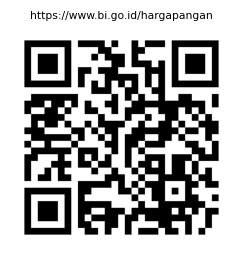

In [7]:
sys.path.insert(0, str(ROOT / "deployment"))
from make_qr import make_qr
url = cfg["deployment"]["dashboard_url"]
if "GANTI" in url:
    print("⚠️ URL dashboard belum diisi di config.yaml — QR contoh dibuat ke URL PIHPS sebagai placeholder.")
    url = "https://www.bi.go.id/hargapangan"
qr_path = make_qr(url, P.figures / "qr_prototipe.png")
from PIL import Image
im = Image.open(qr_path); fig, ax = plt.subplots(figsize=(2.6, 2.6)); ax.imshow(im, cmap="gray"); ax.axis("off"); ax.set_title(url, fontsize=7); plt.show()

## 7.5 Rencana pemantauan & pemeliharaan (*monitoring & maintenance*)

| Aspek | Cara | Pemicu tindakan |
|---|---|---|
| Kesegaran data | Tanggal data terakhir vs hari ini | > 3 hari kerja tanpa data baru → cek scraper/API |
| Kesehatan scraper | Status chunk (`ok/error`) tiap update | Ada `error` → retry; struktur API berubah → perbarui `scraper.py` |
| *Drift* fitur | PSI fitur utama: 60 hari terakhir vs data latih | PSI > 0,25 → latih ulang lebih awal |
| Performa nyata | Setelah 14 hari, bandingkan alarm vs kejadian yang benar-benar terjadi (PR-AUC & deteksi per bulan) | PR-AUC bulanan < baseline naive 2 bulan berturut-turut → evaluasi ulang |
| Pelatihan ulang | `python run_pipeline.py update --retrain` | Rutin bulanan / saat drift |
| Ambang lonjakan | Tinjau frekuensi kejadian per komoditas tiap 6 bulan | Pola harga berubah (mis. kebijakan HET) |

In [8]:
# (a) Kesegaran data
last = feats["date"].max(); today = pd.Timestamp.today().normalize()
lag_bd = len(pd.bdate_range(last + pd.Timedelta(days=1), today)) - 1
print(f"Data terakhir: {last:%d %b %Y} | hari ini: {today:%d %b %Y} | jeda: {max(lag_bd, 0)} hari kerja -> "
      f"{'OK' if lag_bd <= 3 else 'PERLU DICEK'}")

# (b) Drift fitur (Population Stability Index)
def psi(expected, actual, bins=10):
    e = expected[np.isfinite(expected)]; a = actual[np.isfinite(actual)]
    if len(e) < 100 or len(a) < 100: return np.nan
    qs = np.unique(np.quantile(e, np.linspace(0, 1, bins + 1)))
    if len(qs) < 3: return 0.0
    ec = np.histogram(np.clip(e, qs[0], qs[-1]), qs)[0] / len(e); ac = np.histogram(np.clip(a, qs[0], qs[-1]), qs)[0] / len(a)
    ec, ac = np.clip(ec, 1e-4, None), np.clip(ac, 1e-4, None)
    return float(np.sum((ac - ec) * np.log(ac / ec)))
imp_path = P.tables / "06_shap_importance.csv"
top_feats = pd.read_csv(imp_path)["feature"].head(12).tolist() if imp_path.exists() else meta["features"][:12]
recent = feats[feats["date"] > last - pd.Timedelta(days=60)]
train_ref = feats[(feats["date"] <= last - pd.Timedelta(days=74)) & (feats["date"] > last - pd.Timedelta(days=74 + 730))]
drift = pd.DataFrame({"fitur": top_feats, "PSI": [psi(train_ref[f].to_numpy(), recent[f].to_numpy()) for f in top_feats]})
drift["status"] = pd.cut(drift["PSI"], [-1, 0.1, 0.25, 99], labels=["stabil", "perlu dipantau", "drift → latih ulang"])
display(drift.style.format({"PSI": "{:.3f}"}).hide(axis="index"))

Data terakhir: 25 Sep 2026 | hari ini: 27 Sep 2026 | jeda: 0 hari kerja -> OK


fitur,PSI,status
vol_30,0.043,stabil
commodity_code,0.000,stabil
vol_14,0.017,stabil
lead_ret_14_mean,0.066,stabil
province_code,0.000,stabil
lead_ret_7_mean,0.049,stabil
nbr_rel_price,0.008,stabil
ret_7,0.023,stabil
days_since_spike,0.009,stabil
rel_nat,0.010,stabil


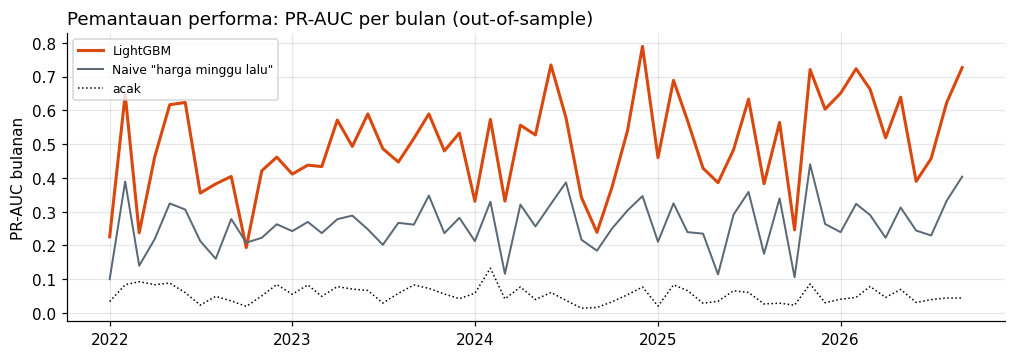

Bulan di mana LightGBM > naive: 98% dari 57 bulan


In [9]:
# (c) Performa per bulan dari prediksi out-of-sample walk-forward (simulasi pemantauan)
from radarpangan.metrics import pr_auc
oof_path = P.processed / "oof_predictions.parquet"
if oof_path.exists():
    oof = pd.read_parquet(oof_path)
    mon = oof.groupby(oof["date"].dt.to_period("M")).apply(lambda g: pd.Series({
        "LightGBM": pr_auc(g["y"], g["score_lgbm"]), "Naive": pr_auc(g["y"], g["score_naive"]), "acak": g["y"].mean()}))
    fig, ax = plt.subplots(figsize=(11, 3.4))
    x = mon.index.to_timestamp()
    ax.plot(x, mon["LightGBM"], color=PALETTE["high"], lw=2, label="LightGBM")
    ax.plot(x, mon["Naive"], color=PALETTE["muted"], lw=1.3, label='Naive "harga minggu lalu"')
    ax.plot(x, mon["acak"], color="k", ls=":", lw=1, label="acak")
    ax.set_ylabel("PR-AUC bulanan"); ax.legend(fontsize=8); ax.set_title("Pemantauan performa: PR-AUC per bulan (out-of-sample)", loc="left")
    fig.savefig(P.figures / "fig_07_02_monitoring.png", dpi=160, bbox_inches="tight"); plt.show()
    print(f"Bulan di mana LightGBM > naive: {(mon['LightGBM'] > mon['Naive']).mean():.0%} dari {len(mon)} bulan")

## 7.6 Cara menjalankan di produksi

**A. Update harian di laptop (Windows)** — `deployment\update_harian.bat` bisa dijadwalkan di *Task Scheduler* setiap hari kerja pukul 16.00:
```bat
cd /d C:\Users\Bio\Documents\USB-DataMining\MiningProcess
python run_pipeline.py update
```
lalu unggah folder `site/` ke hosting (GitHub Pages / Vercel).

**B. Otomatis di cloud (GitHub Actions)** — push folder `MiningProcess` sebagai repo GitHub, aktifkan *Pages → Source: GitHub Actions*. Workflow `.github/workflows/update-dashboard.yml` menjalankan `run_pipeline.py update` setiap hari kerja dan menerbitkan `site/`.

Panduan langkah demi langkah: `deployment/README_deploy.md`.

## 7.7 Tinjauan proyek (*review project*)
- **Berhasil**: pipeline end-to-end dari scraping sampai dashboard; model mengungguli semua baseline pada uji out-of-sample ±4,7 tahun; setiap alarm punya alasan yang bisa dibaca awam; jaringan rambatan tervalidasi pada periode baru.
- **Pelajaran**: definisi target harus menyesuaikan volatilitas komoditas (iterasi Data Understanding → Business Understanding); hipotesis margin produsen–konsumen tidak terbukti, baik secara linear (NB03) maupun di dalam model (ablation NB06) — dilaporkan apa adanya; sinyal yang terbukti penting justru kalender dan rambatan spasial.
- **Laporan akhir**: `README.md`, `docs/`, tabel & grafik di `reports/`, dashboard `site/`.